# 06 — A Market Risk Workup for a Real Portfolio

**Quantitative Markets Research Lab** · risk measurement notebook

This notebook does what a risk team does on a Monday morning, end to end, on real data: define a portfolio, backtest it honestly (costs included, no look-ahead), and then interrogate the return stream with every lens in the risk library — VaR in four flavors, expected shortfall, drawdown anatomy, historical scenario shocks, correlation stress, and the regime break that quietly invalidated a generation of risk models in 2022.

**The portfolio: "60/40 plus alternatives."** A deliberately conventional allocation — the point is the risk workup, not the alpha:

| Sleeve | Assets | Weight |
|---|---|---|
| US equity | SPY 30%, QQQ 10%, IWM 5% | 45% |
| Intl equity | EFA 10% | 10% |
| Bonds | AGG 20%, TLT 10% | 30% |
| Alternatives | GLD 7.5%, VNQ 7.5% | 15% |

Rebalanced monthly back to target through the `Backtester` with 10bp proportional transaction costs. The engine's design invariants matter for credibility: the weight function only ever sees prices *strictly before* each rebalance date, weights drift with returns between rebalances, and turnover is charged against the *drifted* holdings — so the resulting return stream is one a real (if idealized) investor could have earned.

In [1]:
import sys, os, pathlib

ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (9.5, 5), "figure.dpi": 100,
    "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
})
SEED = 42

from src.data.market_data_loader import load_prices, to_returns
from src.backtesting.engine import Backtester
from src.backtesting.transaction_costs import ProportionalCost
from src.backtesting.performance_metrics import summary

TARGET = pd.Series({"SPY": 0.30, "QQQ": 0.10, "IWM": 0.05, "EFA": 0.10,
                    "AGG": 0.20, "TLT": 0.10, "GLD": 0.075, "VNQ": 0.075})
assert abs(TARGET.sum() - 1.0) < 1e-12

prices = load_prices(TARGET.index.tolist())
bt = Backtester(cost_model=ProportionalCost(bps=10.0), rebalance="M")
result = bt.run(prices, lambda window: TARGET, lookback=252)
r = result.returns

print(f"backtest: {len(r)} trading days, {r.index[0].date()} to {r.index[-1].date()}")
print(f"rebalances: {len(result.turnover)},  mean one-sided turnover {result.turnover.mean():.2%},")
print(f"cumulative cost drag {result.costs.sum():.2%} of NAV over the full period")

backtest: 2640 trading days, 2016-01-04 to 2026-07-06
rebalances: 127,  mean one-sided turnover 1.44%,
cumulative cost drag 0.18% of NAV over the full period


Costs are real but small for this strategy — monthly re-anchoring of a drifting balanced book needs only ~1.4% one-sided turnover per rebalance, so a decade of trading costs totals under 20bp. (A momentum strategy would tell a very different story; the engine charges whatever the weight function's turnover earns.)

## 1. The summary card

In [2]:
perf = summary(r, rf=0.02)
perf.round(4)

annualized_return     0.1014
annualized_vol        0.1150
sharpe_ratio          0.7233
sortino_ratio         1.0080
calmar_ratio          0.4166
hit_rate              0.5686
max_drawdown          0.2433
skew                 -0.5429
kurtosis             12.9753
VaR95                 0.0108
ES95                  0.0172
Name: summary, dtype: float64

**Interpretation.** Over 2016–2026 the book earned about **10.1%** a year at **11.5%** volatility — Sharpe ≈ 0.72 against a 2% cash rate, hit rate a modest 57% of days. The distribution shape is the part that deserves attention: skew **−0.54** and excess kurtosis **≈ 13**. A diversified, boring, monthly-rebalanced portfolio still inherits equity markets' asymmetry: its worst days are much worse than its best days are good. Every Gaussian-based number below should be read with that kurtosis in mind — which is exactly why we compute VaR four ways rather than one.

## 2. Value-at-Risk, four ways — and why they disagree

$\text{VaR}_\alpha$ is the loss threshold exceeded on only $(1-\alpha)$ of days:

$$\text{VaR}_\alpha = -\inf\{x : \mathbb{P}(r \le x) \ge 1 - \alpha\}.$$

Four estimators, four philosophies: **historical** (the empirical quantile — no distributional assumption, limited by the sample), **parametric** (Gaussian — smooth, wrong tails), **Cornish–Fisher** (Gaussian corrected by sample skew/kurtosis), and **Monte Carlo** (resampled from a fitted multivariate normal on the assets — flexible machinery, still Gaussian marginals here). Expected shortfall then asks the better question: *given* a VaR breach, how bad is the average of what follows?

$$\text{ES}_\alpha = -\,\mathbb{E}\big[r \mid r \le -\text{VaR}_\alpha\big].$$

,alpha = 95%,alpha = 99%
historical VaR,1.079,1.912
parametric (normal) VaR,1.151,1.645
Cornish-Fisher VaR,1.069,4.047
Monte Carlo VaR,1.166,1.657
historical ES,1.718,3.022
parametric ES,1.454,1.890


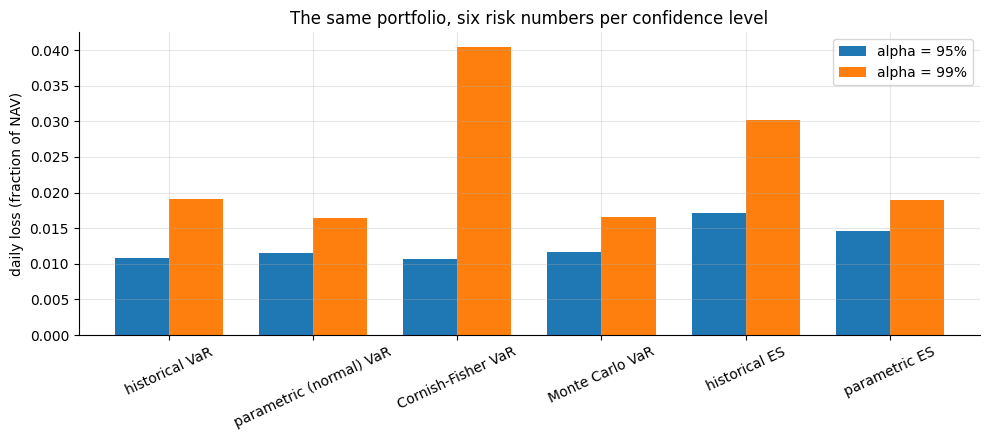

In [3]:
from src.risk.value_at_risk import (historical_var, parametric_var,
                                    cornish_fisher_var, monte_carlo_var)
from src.risk.expected_shortfall import historical_es, parametric_es

asset_rets = to_returns(prices).loc[r.index]
mu_d, cov_d = asset_rets.mean(), asset_rets.cov()
rng = np.random.default_rng(SEED)

var_tab = pd.DataFrame({
    alpha: {
        "historical VaR": historical_var(r, alpha=alpha),
        "parametric (normal) VaR": parametric_var(r, alpha=alpha),
        "Cornish-Fisher VaR": cornish_fisher_var(r, alpha=alpha),
        "Monte Carlo VaR": monte_carlo_var(mu_d, cov_d, TARGET, alpha=alpha,
                                           n_sims=100_000, rng=rng),
        "historical ES": historical_es(r, alpha=alpha),
        "parametric ES": parametric_es(r, alpha=alpha),
    } for alpha in (0.95, 0.99)
})
var_tab.columns = ["alpha = 95%", "alpha = 99%"]

ax = var_tab.plot.bar(figsize=(10, 4.5), width=0.75)
ax.set_ylabel("daily loss (fraction of NAV)")
ax.set_title("The same portfolio, six risk numbers per confidence level")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
(var_tab * 100).round(3)

**Interpretation — the disagreements are the lesson.**

- At **95%**, the four VaRs cluster tightly (≈ 1.07–1.16% of NAV). The Gaussian is slightly the *highest*, and Cornish–Fisher slightly the lowest — surprising until you recall what kurtosis does: it fattens the extreme tail by thinning the *moderate* tail, and the 95% point sits in the moderate tail. At this confidence level, normality flatters no one and costs little.
- At **99%**, the ranking flips and spreads: historical and Cornish–Fisher push well above the Gaussian numbers. This is the kurtosis bill arriving. The Gaussian model's error is not a constant — it is small exactly where VaR is easy and large exactly where VaR matters.
- **ES ≥ VaR always**, and the historical ES exceeds parametric ES by ~20% at 95% — the average breach is worse than a normal distribution expects, again the fat left tail. ES is the regulator's preferred number (FRTB) for precisely this reason: it looks *past* the threshold instead of at it.
- The Monte Carlo VaR agrees with parametric almost exactly — as it must, since it resamples from a fitted Gaussian. Its value is architectural (it prices nonlinear positions and arbitrary weight changes), not distributional. Garbage tails in, garbage tails out.

## 3. Drawdown anatomy

VaR is a one-day number. Investors live in *drawdowns* — multiplicative, path-dependent, and psychologically decisive.

,depth,start,trough,recovery,duration_days
0,0.243305,2021-12-27,2022-10-14,2024-03-21,561
1,0.217114,2020-02-19,2020-03-18,2020-07-10,99
2,0.112688,2018-08-29,2018-12-24,2019-03-15,135
3,0.109504,2025-02-19,2025-04-08,2025-05-16,61
4,0.072014,2026-02-25,2026-03-27,2026-04-17,36


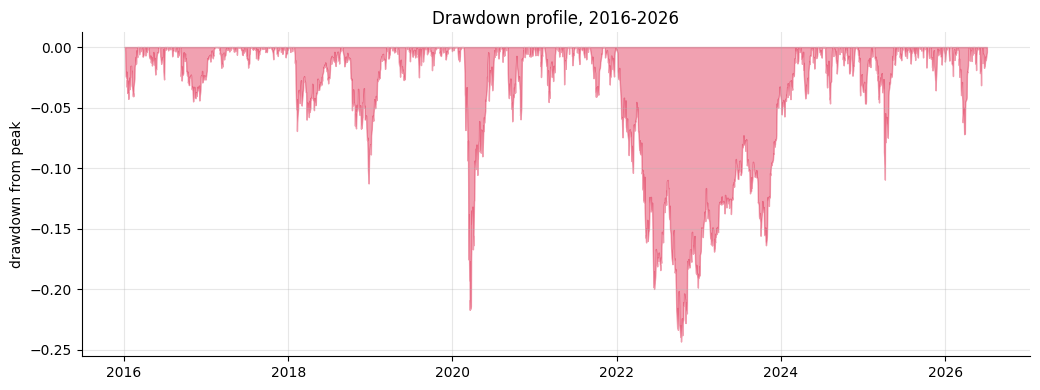

In [4]:
from src.risk.drawdown_analysis import drawdown_series, drawdown_stats

dd = drawdown_series(r)
top5 = drawdown_stats(r)

fig, ax = plt.subplots(figsize=(10.5, 4))
ax.fill_between(dd.index, dd, 0, color="crimson", alpha=0.4)
ax.set_ylabel("drawdown from peak")
ax.set_title("Drawdown profile, 2016-2026")
plt.tight_layout()
top5

**Interpretation.** The two big holes tell opposite stories:

- **Covid 2020**: −21.7% in *twenty trading days* — violent, but recovered within about three months (99 days peak-to-recovery). Bonds and gold did their job; the drawdown was a liquidity spasm, not a regime change.
- **2022 rate shock**: −24.3%, but the drawdown *began December 2021, troughed in October 2022, and did not recover until March 2024* — **561 days** underwater. Shallower per day, far more corrosive: this was the episode where the 30% bond sleeve fell *with* equities, so diversification — the entire design premise of this portfolio — failed simultaneously with the equity decline.

Note what the VaR table could never have told you: the 2022 event was not made of tail *days* (few individual days breached 99% VaR) but of an eleven-month accumulation of ordinary bad days pointing the same direction. Drawdown and VaR measure different risks; a risk report needs both.

## 4. The dashboard view

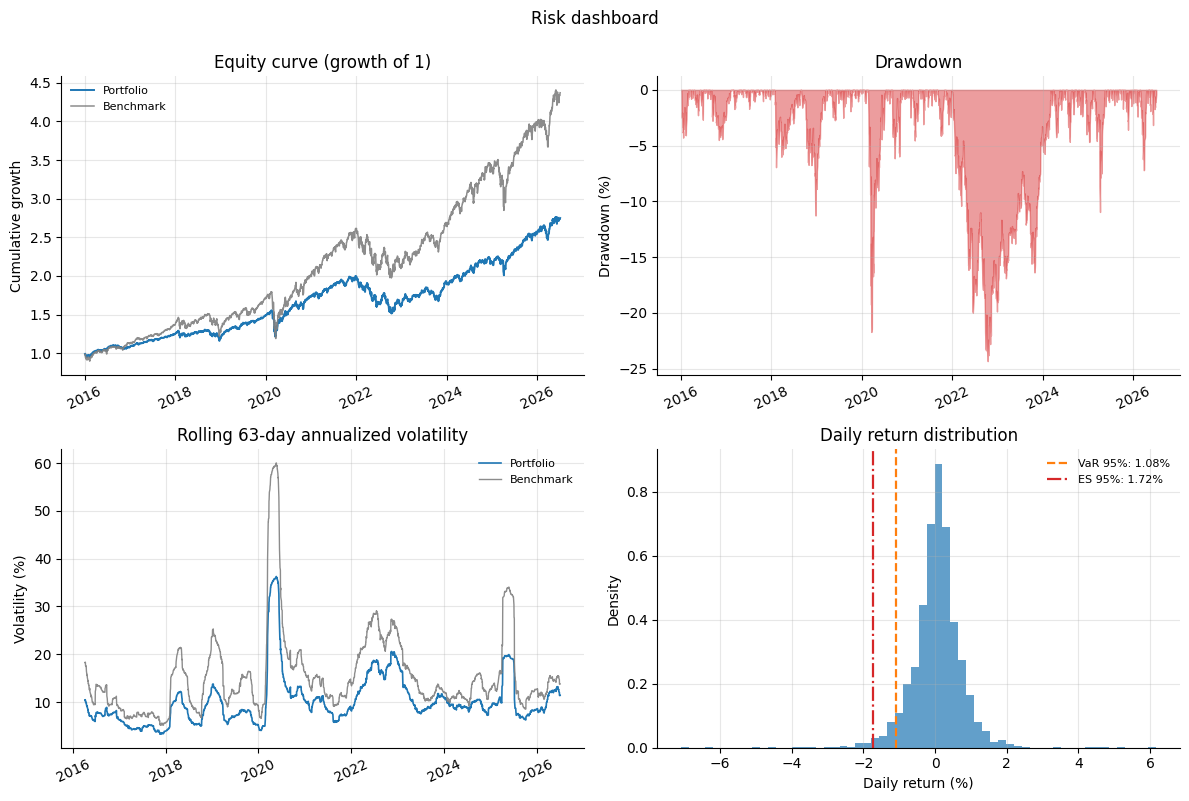

In [5]:
from src.visualization.risk_dashboard import plot_risk_dashboard

spy_bench = to_returns(prices)["SPY"].reindex(r.index)
fig = plot_risk_dashboard(r, benchmark=spy_bench)
fig.set_size_inches(12, 8)
plt.tight_layout()

The four panels compress the story so far: the equity curve compounds below SPY (as a 55%-equity book should), the drawdown panel shows 2020's spike versus 2022's trench, rolling volatility shows the clustering of notebook 03 surviving diversification, and the histogram panel marks where VaR and ES sit inside the empirical left tail.

## 5. Historical scenarios: replaying the disasters we know

Scenario analysis asks a question VaR cannot: *what does this specific portfolio lose if a named historical episode replays?* The library ships approximate peak-to-trough asset-class shocks for four episodes; applying them to today's weights is a matrix multiply, $\Delta P = w^\top s$.

,pnl (%),n_assets_shocked
scenario,,
GFC-2008,-30.5,8
Covid-2020,-20.6,8
RateShock-2022,-24.7,8
DotCom-2000,-23.9,8


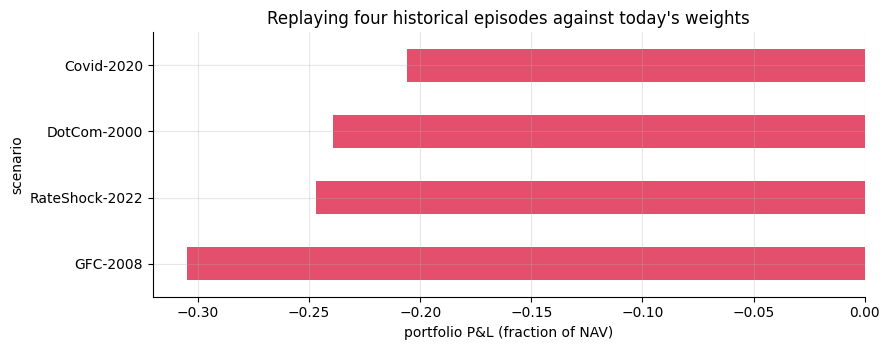

In [6]:
from src.risk.stress_testing import run_scenarios, HISTORICAL_SCENARIOS

scen = run_scenarios(TARGET, HISTORICAL_SCENARIOS)
ax = scen["pnl"].sort_values().plot.barh(figsize=(9, 3.6), color="crimson", alpha=0.75)
ax.set_xlabel("portfolio P&L (fraction of NAV)")
ax.set_title("Replaying four historical episodes against today's weights")
plt.tight_layout()
(scen.assign(pnl=lambda d: (d["pnl"] * 100).round(1))
     .rename(columns={"pnl": "pnl (%)"}))

**Interpretation.** A GFC replay costs this book about **−30%**; Covid about **−21%** (closely matching the realized 2020 drawdown — a reassuring calibration check); the 2022 rate shock **−25%**; dot-com **−24%**. Two observations with teeth:

1. **The rate-shock scenario is nearly as bad as the GFC for this portfolio** despite equity shocks half the size — because it is the only scenario where the 30% bond sleeve *adds* to the loss (−17% AGG, −33% TLT) instead of offsetting it. Scenario tables reveal *which* diversification a portfolio actually depends on.
2. These are static shocks to today's weights: no rebalancing, no flight-to-quality timing, no second-round effects. They are floor-level estimates of episodes we already know about — and the next crisis is under no obligation to resemble the last four.

## 6. Correlation stress: watching diversification evaporate

The oldest cruelty in markets: correlations rise exactly when you need them low. We stress the covariance matrix by blending its correlation block toward 1, $\rho^{\text{stress}} = (1-\lambda)\rho + \lambda\mathbf{1}\mathbf{1}^\top$ (volatilities untouched, PSD enforced), and track portfolio volatility.

vol at lambda=0: 11.64%   lambda=0.5: 13.86%   lambda=1: 15.76%


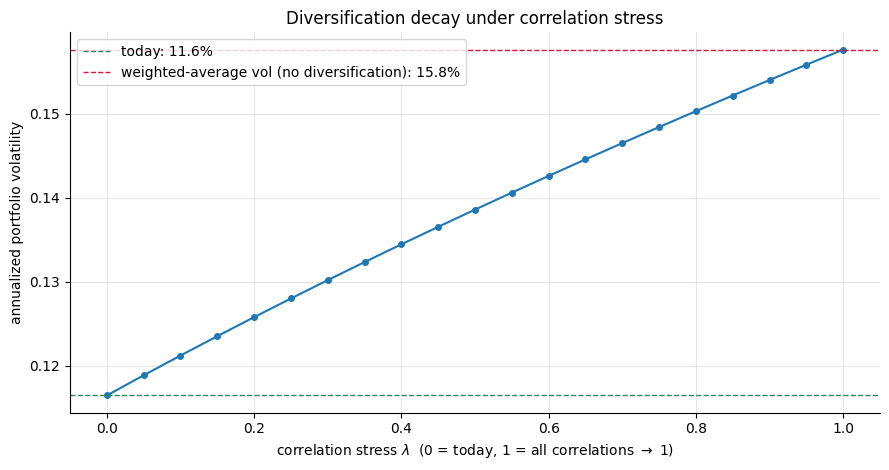

In [7]:
from src.risk.stress_testing import correlation_stress

cov_ann = cov_d * 252
lambdas = np.linspace(0, 1, 21)
vols = [float(np.sqrt(TARGET @ correlation_stress(cov_ann, float(l)) @ TARGET))
        for l in lambdas]
undiversified = float(TARGET @ np.sqrt(np.diag(cov_ann)))   # perfect-correlation limit

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(lambdas, vols, "o-", ms=4)
ax.axhline(vols[0], color="seagreen", ls="--", lw=1, label=f"today: {vols[0]:.1%}")
ax.axhline(undiversified, color="crimson", ls="--", lw=1,
           label=f"weighted-average vol (no diversification): {undiversified:.1%}")
ax.set_xlabel(r"correlation stress $\lambda$  (0 = today, 1 = all correlations $\to$ 1)")
ax.set_ylabel("annualized portfolio volatility")
ax.set_title("Diversification decay under correlation stress")
ax.legend()
plt.tight_layout()
print(f"vol at lambda=0: {vols[0]:.2%}   lambda=0.5: {vols[10]:.2%}   lambda=1: {vols[-1]:.2%}")

**Interpretation.** Today's correlation structure lets an 11.6%-vol portfolio be built from parts averaging ~15.8%: diversification is "earning" about 4 vol points. Pushing correlations halfway to 1 claws back ~2.2 of those points; at $\lambda = 1$ the portfolio is just the weighted sum of its parts. The curve is the price list for the portfolio's key hidden assumption — and 2022 was a real-world sample from the middle of it.

## 7. The regime break: SPY–TLT correlation

The design of every 60/40-style portfolio rests on one empirical regularity: stock–bond correlation was reliably negative from roughly 2000 to 2021, so Treasuries acted as crisis insurance. Watch it break.

mean correlation 2015-2019: -0.35
peak correlation 2022-2023: +0.37
latest value:               +0.31


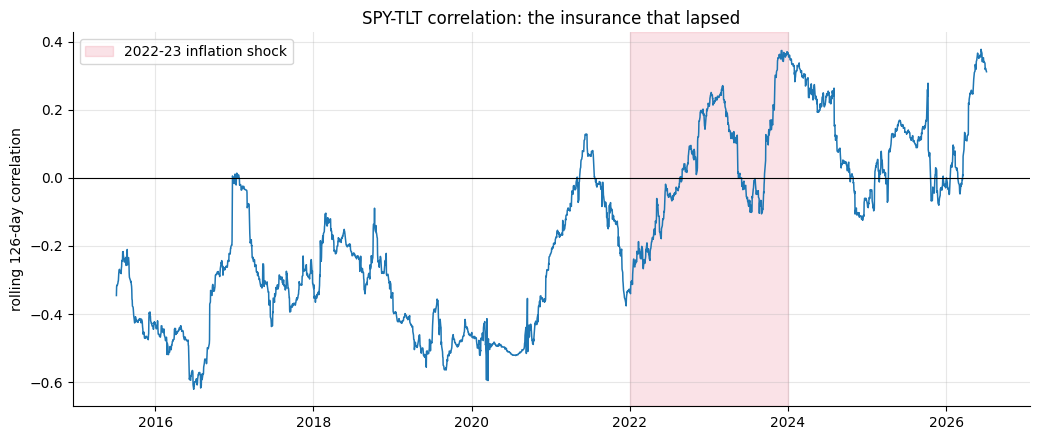

In [8]:
wide = to_returns(load_prices(["SPY", "TLT"]))
roll_corr = wide["SPY"].rolling(126).corr(wide["TLT"])

fig, ax = plt.subplots(figsize=(10.5, 4.5))
ax.plot(roll_corr, lw=1.1)
ax.axhline(0, color="k", lw=0.8)
ax.axvspan(pd.Timestamp("2022-01-01"), pd.Timestamp("2023-12-31"),
           alpha=0.12, color="crimson", label="2022-23 inflation shock")
ax.set_ylabel("rolling 126-day correlation")
ax.set_title("SPY-TLT correlation: the insurance that lapsed")
ax.legend()
plt.tight_layout()
print(f"mean correlation 2015-2019: {roll_corr.loc[:'2019'].mean():+.2f}")
print(f"peak correlation 2022-2023: {roll_corr.loc['2022':'2023'].max():+.2f}")
print(f"latest value:               {roll_corr.iloc[-1]:+.2f}")

**Interpretation.** For 2015–2019 the correlation averaged **−0.35**: on bad equity days, bonds rallied, and every risk model calibrated on that era "knew" it. Through 2022–23 it swung to **+0.37** — a ~0.7 swing in the single most load-bearing correlation in institutional portfolio construction — and it remains positive (**+0.31**) at the end of our sample. The mechanism is well understood *after the fact*: when inflation drives the discount rate, stocks and bonds share a common factor; when growth fear drives it, they oppose. The uncomfortable part is that a decade of daily data (2,500 observations!) provided precisely zero warning, because all 2,500 observations were drawn from one regime.

This single chart is the strongest argument in the whole notebook for scenario analysis and correlation stress as *complements* to statistical risk measures: the statistics can only summarize the regime they were fed.

## 8. Closing: lenses, not shields

A last accounting of what each instrument in this workup can and cannot see:

- **VaR** sees the ordinary tail, one day at a time; it is silent about breach severity, and its Gaussian variants understate exactly the confidence levels that matter.
- **ES** sees breach severity; it still extrapolates from the sample it was given.
- **Drawdown analysis** sees path and duration — the investor's lived experience — but only for paths that already happened.
- **Scenarios** see named catastrophes, at the cost of assuming the future rhymes with a four-item past.
- **Correlation stress** sees the fragility of diversification, without telling you *when* it will be tested.
- **The backtest** underneath it all is honest about costs and look-ahead — and still describes exactly one draw of history.

None of these is a shield. A portfolio does not lose less because its VaR was computed carefully. They are lenses — each with a known blind spot, chosen so the blind spots do not fully overlap. The risk manager's real deliverable is not the number but the sentence after it: *here is what this measure cannot see.* Risk models are lenses, not shields; models clarify uncertainty — they do not eliminate it.